# Homework #6

## Performance measures

This colaboratory also contains **Homework #6** of the Machine Learning course, which is due **April 18, midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

Pooh

##List of Homework's exercises:

1.   [Ex1](#scrollTo=Va-cdXRPJ0qZ) - 3 points
2.   [Ex2](#scrollTo=lbbE3lltHbA_) - 3 points
3.   [Ex3](#scrollTo=lbbE3lltHbA_) - 4 points


In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# For plotting like a pro (actually, no)
!pip install -q plotnine
from plotnine import *



---

## Homework exercise 1: compute macro and weighted averages for precision, recall and f1-score on an unbalanced dataset (3 points)


<font color='red'> In this exercise we will start with training a logistic regression on a small artificial dataset. Next, you will calculate ordinary recall, precision and f1 measures and their macro- and weighted average versions. Learn more about macro and weighted averages here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html  </font>


In [2]:
# Generating an unbalanced dataset
from sklearn import datasets

# this function we have already used in HW2
# note that we have 250 instances of class 0 and only 50 of class 1
unequal_noisy_moons = datasets.make_moons(n_samples=(250, 50),
                                          noise=.4,
                                          random_state=1)

unequal_noisy_moons = pd.DataFrame({'x1':unequal_noisy_moons[0][:,0],
                            'x2':unequal_noisy_moons[0][:,1],
                            'class':unequal_noisy_moons[1]})

unequal_noisy_moons['class'] = unequal_noisy_moons['class'].astype('category')

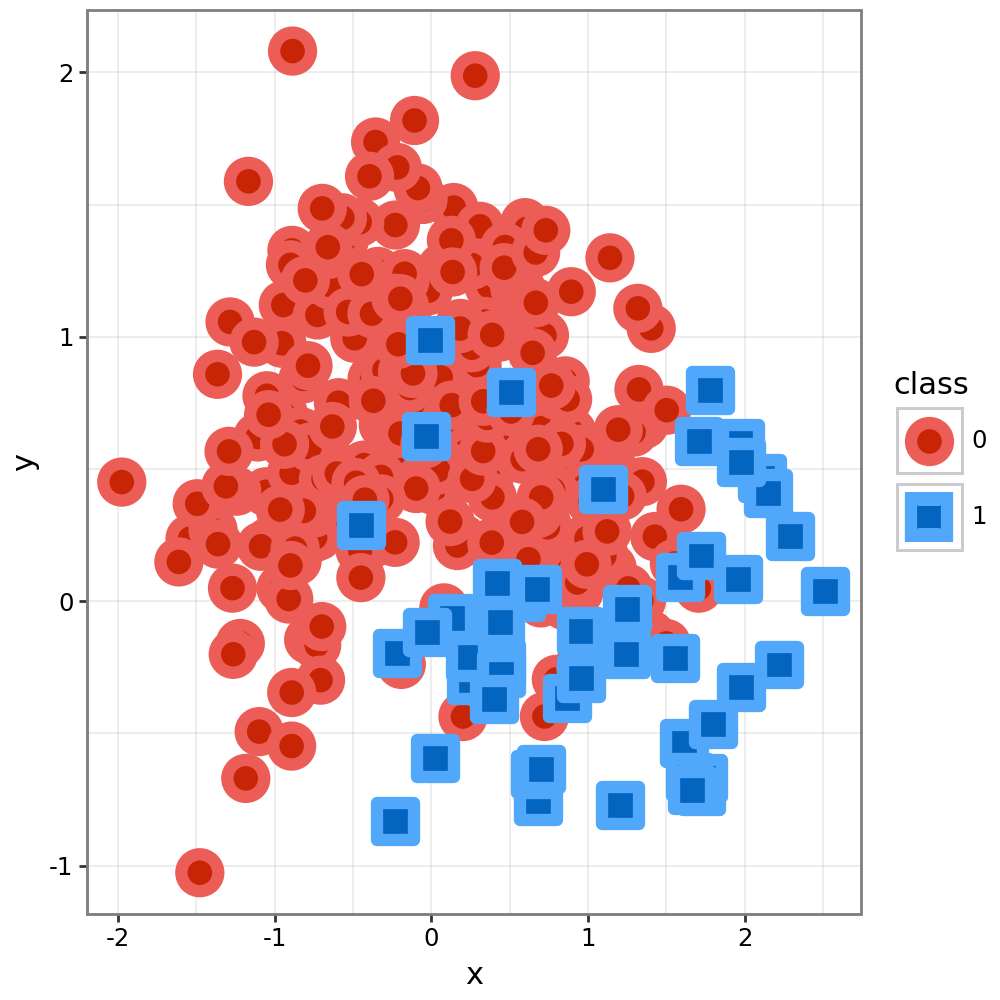

In [3]:
fig = (
    ggplot(data = unequal_noisy_moons,
          mapping = aes(x = 'x1', y = 'x2')) +
    geom_point(aes(colour = 'class',
                   shape = 'class',
                   fill = 'class'),
               size = 5.0,
               stroke = 2.5) +
    labs(
        title ='',
        x = 'x',
        y = 'y',
    ) +
    theme_bw() +
    scale_color_manual(['#EC5D57', '#51A7F9']) +
    scale_fill_manual(['#C82506', '#0365C0']) +
    scale_shape_manual(['o', 's']) +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
)

fig

In [4]:
# train a classifier
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression()
logit.fit(unequal_noisy_moons[['x1', 'x2']], unequal_noisy_moons[['class']])

LogisticRegression()

In [5]:
# predicting on train
predictions = logit.predict(unequal_noisy_moons[['x1', 'x2']])

<font color='red'>  **(Homework exercise 1- a)** Fill in the gaps to complete a function that calculates `tp`, `fn`, `fp`, `tn` depending on which class is considered to be `positive`.  **(1 point)**</font>

In [6]:
import math

def compute_confusion_stats(labels, predictions, positive_class, negative_class):
  #### YOUR CODE STARTS ####
  pred_positive = np.array(predictions) == positive_class
  real_positive = np.array(labels) == positive_class

  pred_negative = np.array(predictions) == negative_class
  real_negative = np.array(labels) == negative_class

  tp = np.sum((pred_positive == real_positive) & (real_positive == True))
  fn = np.sum((pred_negative == real_positive) & (pred_negative == True))
  fp = np.sum((pred_positive == real_negative) & (pred_positive == True))
  tn = np.sum((pred_negative == real_negative) & (real_negative == True))
  #### YOUR CODE ENDS ####

  return (tp, fn, fp, tn)

def compute_rec_prec_f1(tp, fn, fp, tn):
  recall = tp/(tp + fn)
  precision = tp/(tp + fp)
  f1 = 2*recall*precision/(precision + recall)
  if math.isnan(f1):
    f1 = 0
  return (recall, precision, f1)

<font color='red'> Compute `tp`, `fn`, `fp`, `tn` and `recall`, `precision` and `f1` measures using functions `compute_confusion_stats` and `compute_rec_prec_f1` above. `recall`, `precision` and `f1` should be computed for both classes, e.g. `recall_1` is a recall when the first class is considered to be positive, `recall_0` is a recall when the second class is regarded as positive.</font>




In [7]:
# The first class is considered positive
#### YOUR CODE STARTS ####
(tp, fn, fp, tn) = compute_confusion_stats(unequal_noisy_moons['class'], predictions, np.unique(predictions)[0], np.unique(predictions)[1])
recall_1, precision_1, f1_1 = compute_rec_prec_f1(tp, fn, fp, tn)
#### YOUR CODE ENDS ####

print(f'Recall for the first class = {recall_1}')
print(f'Precision for the first class = {precision_1}')
print(f'F1 score for the first class = {f1_1}')

Recall for the first class = 0.964
Precision for the first class = 0.909433962264151
F1 score for the first class = 0.9359223300970874


In [8]:
# The second class is considered positive
#### YOUR CODE STARTS ####
(tp, fn, fp, tn) = compute_confusion_stats(unequal_noisy_moons['class'], predictions, np.unique(predictions)[1], np.unique(predictions)[0])
recall_0, precision_0, f1_0 = compute_rec_prec_f1(tp, fn, fp, tn)
#### YOUR CODE ENDS ####

print(f'Recall for the second class = {recall_0}')
print(f'Precision for the second class = {precision_0}')
print(f'F1 score for the second class = {f1_0}')

Recall for the second class = 0.52
Precision for the second class = 0.7428571428571429
F1 score for the second class = 0.6117647058823529


<font color='red'>  **(Homework exercise 1- b)** Without using any external libraries, calculate macro and weighted averages for all metrics. Run the `classification_report` function from `sklearn`, make sure that the outputs match. **(1 point)**</font>

In [9]:
#### YOUR CODE STARTS ####

macro_avg_precision = np.mean([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[1] for i in np.unique(unequal_noisy_moons['class'])])
print(f'Macro averaging for precision = {np.round(macro_avg_precision,2)}')

macro_avg_recall = np.mean([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[0] for i in np.unique(unequal_noisy_moons['class'])])
print(f'Macro averaging for recall = {np.round(macro_avg_recall,2)}')

macro_avg_f1 = np.mean([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])
print(f'Macro averaging for f1 = {np.round(macro_avg_f1,2)}')
#### YOUR CODE ENDS ####

Macro averaging for precision = 0.83
Macro averaging for recall = 0.74
Macro averaging for f1 = 0.77


In [10]:
#### YOUR CODE STARTS ####
weight = [np.sum(unequal_noisy_moons['class'] == i) / len(unequal_noisy_moons['class']) for i in np.unique(unequal_noisy_moons['class'])]

whole_precision = np.array([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[1] for i in np.unique(unequal_noisy_moons['class'])])

weighted_avg_precision = np.sum(weight * whole_precision)
print(f'Weighted averaging for precision = {np.round(weighted_avg_precision,2)}')

whole_recall = np.array([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[0] for i in np.unique(unequal_noisy_moons['class'])])

weighted_avg_recall = np.sum(weight * whole_recall)
print(f'Weighted averaging for recall = {np.round(weighted_avg_recall,2)}')

whole_f1 = np.array([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])
weighted_avg_f1 = np.sum(weight * whole_f1)

print(f'Weighted averaging for f1 = {np.round(weighted_avg_f1,2)}')
#### YOUR CODE ENDS ####

Weighted averaging for precision = 0.88
Weighted averaging for recall = 0.89
Weighted averaging for f1 = 0.88


<font color='red'>  Compare all your results with the output of `classification_report` function. Make sure they are the same. </font>

In [11]:
from sklearn.metrics import classification_report
#### YOUR CODE STARTS ####
print(classification_report(unequal_noisy_moons['class'], predictions))
#### YOUR CODE ENDS ####

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       250
           1       0.74      0.52      0.61        50

    accuracy                           0.89       300
   macro avg       0.83      0.74      0.77       300
weighted avg       0.88      0.89      0.88       300



<font color='red'>  **(Homework exercise 1- c)** Use a different classifier on the same dataset. Calculate only weighted- and macro- average f1 score as we have just done for `LogisticRegression`. Compare the obtained results to figure out which classifier is better. **(1 point)**</font>

In [12]:
#### YOUR CODE STARTS ####
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

weight = [np.sum(unequal_noisy_moons['class'] == i) / len(unequal_noisy_moons['class']) for i in np.unique(unequal_noisy_moons['class'])]

model1 = DecisionTreeClassifier(max_depth = 1)
model2 = KNeighborsClassifier(n_neighbors = 5)

model1.fit(unequal_noisy_moons[['x1', 'x2']], unequal_noisy_moons['class'])
model2.fit(unequal_noisy_moons[['x1', 'x2']], unequal_noisy_moons['class'])

predictions1 = model1.predict(unequal_noisy_moons[['x1', 'x2']])
predictions2 = model2.predict(unequal_noisy_moons[['x1', 'x2']])


macro_avg_f1_decision = np.mean([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions1, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])
macro_avg_f1_knn = np.mean([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions2, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])

print(f'Macro avg f1 for DecisionTreeClassifier = {np.round(macro_avg_f1_decision,2)}')
print(f'Macro avg f1 for KNeighborsClassifier = {np.round(macro_avg_f1_knn,2)}')


whole_f1_decision = np.array([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions1, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])
w_avg_f1_decision = np.sum(weight * whole_f1_decision)

whole_f1_knn = np.array([compute_rec_prec_f1(*compute_confusion_stats(unequal_noisy_moons['class'], predictions2, i, np.unique(unequal_noisy_moons['class'])[np.unique(unequal_noisy_moons['class']) != i][0]))[2] for i in np.unique(unequal_noisy_moons['class'])])
w_avg_f1_knn = np.sum(weight * whole_f1_knn)

print(f'Weighted avg f1 for DecisionTreeClassifier = {np.round(w_avg_f1_decision,2)}')
print(f'Weighted avg f1 for KNeighborsClassifier = {np.round(w_avg_f1_knn,2)}')
#### YOUR CODE ENDS ####

Macro avg f1 for DecisionTreeClassifier = 0.75
Macro avg f1 for KNeighborsClassifier = 0.85
Weighted avg f1 for DecisionTreeClassifier = 0.88
Weighted avg f1 for KNeighborsClassifier = 0.92




---

## Homework exercise 2: compare multiple classification methods using precision-recall curve (3 points)


<font color='red'> In the lecture and practice session we have discussed how receiver operating characteristic (ROC) and the corresponding area under this curve (AUC) can be used to assess classifier's performance. Although, being super popular and in majority cases adequate, ROC AUC can be overly optimistic when used on classifiers trained on severely imbalanced data. Another metric, namely - Precision-Recall Curve (PRC) is considered more appropriate for such data. In this exercise, we will learn to build PRC and use it to evaluate already familiar classifiers. Check out [this page](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-imbalanced-classification/) if you want to know more about PRCs. </font>



In [13]:
# Using the same data as in the previous exercise
from sklearn import datasets

unequal_noisy_moons = datasets.make_moons(n_samples=(250, 50),
                                          noise=.4,
                                          random_state=111)

unequal_noisy_moons = pd.DataFrame({'x1':unequal_noisy_moons[0][:,0],
                            'x2':unequal_noisy_moons[0][:,1],
                            'class':unequal_noisy_moons[1]})

unequal_noisy_moons['class'] = unequal_noisy_moons['class'].astype('category')

In [14]:
from sklearn.model_selection import train_test_split

# Randomly splitting data into train (60%) and validation (40%)
train, val = train_test_split(unequal_noisy_moons, random_state=0, test_size=0.40)

<font color='red'>  **(Homework exercise 2- a)** Train three models (decision tree, KNN and random forest) on the synthetic data that we have generated above. Calculate accuracy for each model on validation set using function `score` and model objects. Separately, compute and print out the accuracy of the majority class classifier (*hint*: you can use `DummyClassifier` from `sklearn` to imitate majority class classifier).  **(1 point)**</font>

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(1111) # random seed for consistency

#### YOUR CODE STARTS ####
# define all three classifiers using default parameters
DT = DecisionTreeClassifier()
KNN = KNeighborsClassifier()
RF = RandomForestClassifier()

# train classifiers
DT.fit(train[['x1', 'x2']], train['class'])
KNN.fit(train[['x1', 'x2']], train['class'])
RF.fit(train[['x1', 'x2']], train['class'])

# dt_pred = DT.predict(val[['x1', 'x2']])
# knn_pred = KNN.predict(val[['x1', 'x2']])
# rf_pred = RF.predict(val[['x1', 'x2']])

#### YOUR CODE ENDS ####

RandomForestClassifier()

In [16]:
#### YOUR CODE STARTS ####
from sklearn.dummy import DummyClassifier

# print(f"Accuracy of DT is {np.sum(dt_pred == val['class']) / len(dt_pred) * 100}%")
# print(f"Accuracy of KNN is {np.sum(knn_pred == val['class']) / len(knn_pred) * 100}%")
# print(f"Accuracy of RF is {np.sum(rf_pred == val['class']) / len(rf_pred) * 100}%")

print(f"Accuracy of DT is {DT.score(val[['x1', 'x2']], val['class']) * 100}%")
print(f"Accuracy of KNN is {KNN.score(val[['x1', 'x2']], val['class']) * 100}%")
print(f"Accuracy of RF is {RF.score(val[['x1', 'x2']], val['class']) * 100}%")

dummy = DummyClassifier(strategy = 'most_frequent')
dummy.fit(train[['x1', 'x2']], train['class'])

res = dummy.predict(val[['x1', 'x2']])

# print(np.unique(res))

# print(f"Accuracy of majority class classifier is {np.sum(res == val['class']) / len(res) * 100}%")

print(f"Accuracy of majority class classifier is {dummy.score(val[['x1', 'x2']], val['class']) * 100}%")

#### YOUR CODE ENDS ####

Accuracy of DT is 84.16666666666667%
Accuracy of KNN is 95.0%
Accuracy of RF is 90.83333333333333%
Accuracy of majority class classifier is 85.0%


<font color='red'> Get probability scores for the positive class on the validation data from all four models (including the majority class classifier). </font>

In [17]:
#### YOUR CODE STARTS ####
val['DT'] = DT.predict_proba(val[['x1', 'x2']])[:, 1]
val['KNN'] = KNN.predict_proba(val[['x1', 'x2']])[:, 1]
val['RF'] = RF.predict_proba(val[['x1', 'x2']])[:, 1]
val['MAJORITY'] = dummy.predict_proba(val[['x1', 'x2']])[:, 1] # majority class
#### YOUR CODE ENDS ####

<font color='red'>  **(Homework exercise 2- b)** Here we implement and visualise PR curves for the classifiers built in the previous subtask (2-a). **(1 point)**</font>

<font color='red'>  Transform the function `generate_coordinates` from the practice session into a new function `generate_PR_coordinates` such that the latter instead of FPRs and TPRs computes Precision and Recall for each possible threshold. </font>

In [18]:
def generate_PR_coordinates(scores, classes):

  # thresholds can be obtained from scores
  thresholds = scores.unique()

  # initialise
  precisions = []
  recalls = []

  for threshold in thresholds:

    predictions = scores >= threshold
    pred_positive = classes[predictions == 1]
    pred_negative = classes[predictions == 0]

    tp = np.sum(pred_positive == 1)
    fn = np.sum(pred_negative == 1)
    tn = np.sum(pred_negative == 0)
    fp = np.sum(pred_positive == 0)

    ##### YOUR CODE STARTS #####

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    ##### YOUR CODE ENDS #####

    recalls.append(recall)
    precisions.append(precision)

  pr_coordinates = pd.DataFrame({'PRECISION': np.round(precisions, 3),
                                 'RECALL': np.round(recalls, 3)},
                                index=thresholds)

  return pr_coordinates

<font color='red'> Create PRC coordinates for each model using `generate_PR_coordinates`. </font>

In [19]:
#### YOUR CODE STARTS ####
val = val.sort_values('DT',  ascending=False) # do not change sort lines
dt_pr_coordinates = generate_PR_coordinates(val['DT'], val['class'])

val = val.sort_values('KNN',  ascending=False)
knn_pr_coordinates = generate_PR_coordinates(val['KNN'], val['class'])

val = val.sort_values('RF',  ascending=False)
rf_pr_coordinates = generate_PR_coordinates(val['RF'], val['class'])

val = val.sort_values('MAJORITY',  ascending=False)
majority_pr_coordinates = generate_PR_coordinates(val['MAJORITY'], val['class'])

#### YOUR CODE ENDS ####

In [20]:
# Note that our PRCs will start from 1,0 not 0,0 in case of ROCs
top_row = pd.DataFrame({'PRECISION':1, 'RECALL':0}, index=[1.0])

#### YOUR CODE STARTS ####
final_dt_pr_coordinates = pd.concat([top_row, dt_pr_coordinates])
final_knn_pr_coordinates = pd.concat([top_row, knn_pr_coordinates])
final_rf_pr_coordinates = pd.concat([top_row, rf_pr_coordinates])
final_majority_pr_coordinates = pd.concat([top_row, majority_pr_coordinates])
#### YOUR CODE ENDS ####

<font color='red'> Next, use function `plot_pr` which was provided to you to visualise PRCs for all four models. </font>

In [21]:
def plot_pr(coordinates_dict):
  """
  plot_pr function plots all models' PRCs on one plot
  """
  plotting_data = pd.DataFrame(columns=['PRECISION', 'RECALL', 'Method'])

  for id, name in enumerate(coordinates_dict.keys()):
    method_data = coordinates_dict[name]
    method_data['Method'] = name
    plotting_data = pd.concat([plotting_data, method_data])

  plotting_data['Method'] = pd.Categorical(plotting_data['Method'])

  # To those of you who are interested in what the hell is going on
  # check the comments for each line:
  roc_plot = (
        ggplot(data = plotting_data, # creates a canvas
        mapping = aes(x = 'RECALL', y = 'PRECISION', colour = 'Method')) + # specifies dimensions
        geom_path(size = 1.5) + # determines geometric primitive to be visualised (path/line in our case) and its thickness
        labs(title ='', x = 'RECALL', y = 'PRECISION') + # labels of the x and y axes
        # this is all for the figure, beloow are only formatting specs
        theme_bw() + # colour schema
        theme(figure_size = (5, 5), # figure size
              axis_line = element_line(size = 0.5, colour = "black"),
              panel_grid_major = element_line(size = 0.05, colour = "black"),
              panel_grid_minor = element_line(size = 0.05, colour = "black"),
              axis_text = element_text(colour ='black')) # more formatting details
      )
  return roc_plot


<font color='red'>  Visualise the resulting PR curves below. </font>

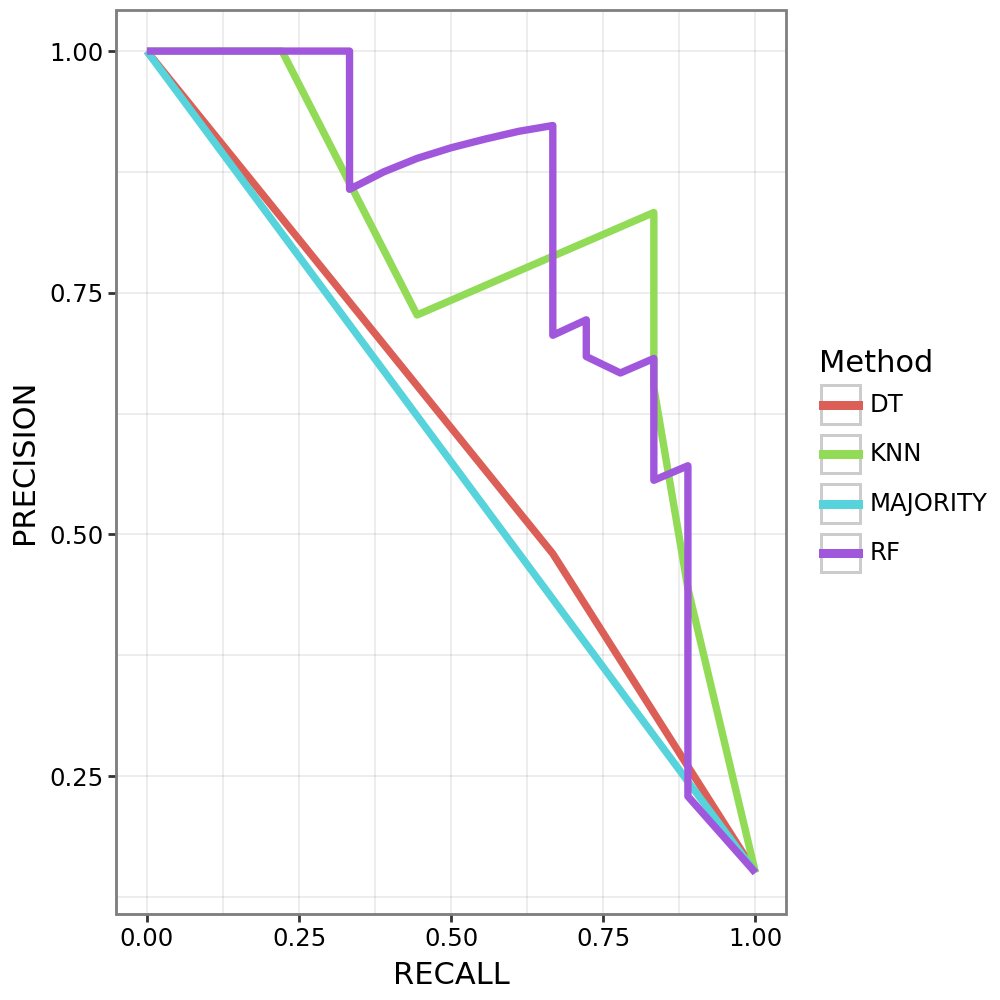

In [22]:
#### YOUR CODE STARTS ####
plot_pr({
    'DT': final_dt_pr_coordinates,
    'KNN': final_knn_pr_coordinates,
    'RF': final_rf_pr_coordinates,
    'MAJORITY': final_majority_pr_coordinates
})
#### YOUR CODE ENDS ####

<font color='red'>  **(Homework exercise 2- c)** Use sklearn functions `PrecisionRecallDisplay` and `precision_recall_curve` and matplotlib to verify that your curves from 2-b are correct. **(0.5 points)**</font>

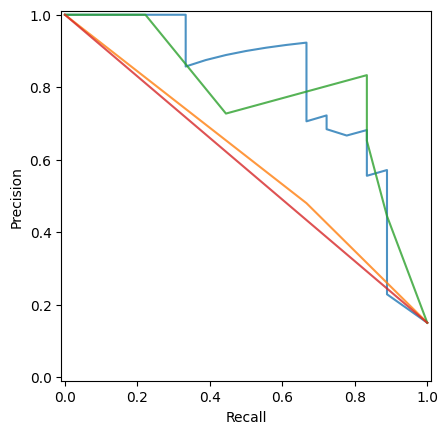

In [23]:
#Importing the required libraries
from sklearn.metrics._plot.precision_recall_curve import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
ax = plt.gca()

#### YOUR CODE STARTS ####

precision_, recall_, _ = precision_recall_curve(val['class'], val['DT'])
dt_disp = PrecisionRecallDisplay(precision_, recall_)

precision_, recall_, _ = precision_recall_curve(val['class'], val['KNN'])
knn_disp = PrecisionRecallDisplay(precision_, recall_)

precision_, recall_, _ = precision_recall_curve(val['class'], val['RF'])
rf_disp = PrecisionRecallDisplay(precision_, recall_)

precision_, recall_, _ = precision_recall_curve(val['class'], val['MAJORITY'])
majority_disp = PrecisionRecallDisplay(precision_, recall_)

#### YOUR CODE ENDS ####

rf_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')
dt_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')
knn_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')
majority_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')

<font color='red'>  **(Homework exercise 2- d)** Create two ensembles: VotingClassifier (with soft voting) and StackingClassifier using previously used models. Visualise performances of the ensembles using PRCs. Add PRCs from the previous models on the same plot for the comparison. **(0.5 points)**</font>

In [24]:
np.random.seed(1111) # random seed for consistency

# Voting classifier comes here:
from sklearn.ensemble import VotingClassifier

#### YOUR CODE STARTS ####
ensemble_model = VotingClassifier([("DT", DT), ("KNN", KNN), ("RF", RF)], voting = 'soft')
ensemble_model.fit(train[['x1', 'x2']], train['class'])

val['VOTING'] = ensemble_model.predict_proba(val[['x1', 'x2']])[:, 1]
val = val.sort_values('VOTING', ascending=False)
voting_pr_coordinates = generate_PR_coordinates(val['VOTING'], val['class'])

final_voting_pr_coordinates = pd.concat([top_row, voting_pr_coordinates])
#### YOUR CODE ENDS ####

# Stacking comes here:
from sklearn.ensemble import StackingClassifier
#### YOUR CODE STARTS ####
estimators = [("DT", DT), ("KNN", KNN), ("RF", RF)]
stacking_classifier = StackingClassifier(estimators = estimators, final_estimator = LogisticRegression())
stacking_classifier.fit(train[['x1', 'x2']], train['class'])

val['STACKING'] = stacking_classifier.predict_proba(val[['x1', 'x2']])[:, 1]

val = val.sort_values('STACKING', ascending=False)
stacking_pr_coordinates = generate_PR_coordinates(val['STACKING'], val['class'])

final_stacking_pr_coordinates = pd.concat([top_row, stacking_pr_coordinates])
#### YOUR CODE ENDS ####

<font color='red'>  Visualise the resulting PR curves below. </font>

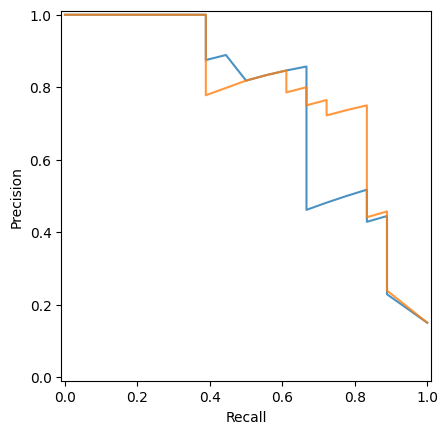

In [25]:
#### YOUR CODE STARTS ####
ax = plt.gca()

precision_, recall_, _ = precision_recall_curve(val['class'], val['VOTING'])
voting_disp = PrecisionRecallDisplay(precision_, recall_)

precision_, recall_, _ = precision_recall_curve(val['class'], val['STACKING'])
stacking_disp = PrecisionRecallDisplay(precision_, recall_)

voting_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')
stacking_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default')
#### YOUR CODE ENDS ####

## Homework exercise 3: Assessing classifier's performance on heavily unbalanced credit loan dataset (4 points)

<font color='red'>  Load the dataset and depending on the choice of the classifier perform necessary pre-processing steps. </font>

In [26]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import pandas as pd

# Fetching the 'Credit-g' dataset from OpenML
# This dataset classifies people described by a
# set of attributes as good or bad credit risks.
# https://www.openml.org/search?type=data&sort=runs&id=31
dataset = fetch_openml(name='credit-g')

In [27]:
dataset.data.describe(include = 'all') # explore the dataset

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,NaN,car,NaN,none,own,NaN,skilled,NaN,none,yes
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,2.845000,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,1.103718,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,4.000000,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN


In [28]:
# Convert to DataFrame for easier analysis
data = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
target = pd.Series(dataset.target)

# Depending on the method you are going to use,
# add your preprocessing code in the block below

#### YOUR CODE STARTS ####

# target = target.astype(str)
# target[target == "good"] = 1
# target[target == "bad"] = 0

target = pd.Series(dataset.target).map({'good': 1, 'bad': 0}).astype(int)

data = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)

data = pd.get_dummies(data, drop_first = True).astype(int)

data.columns = [f'feature_{i}' for i in range(data.shape[1])]
#### YOUR CODE ENDS ####

In [29]:
# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42)

<font color='red'>  **(Homework exercise 3- a)** Explore the class distribution of the dataset. Train a classifier on the original dataset. Evaluate it on the test set using several performance metrics.  **(1 point)**</font>

<font color='red'> Plot the histogram of the class distribution below.</font>

<Axes: >

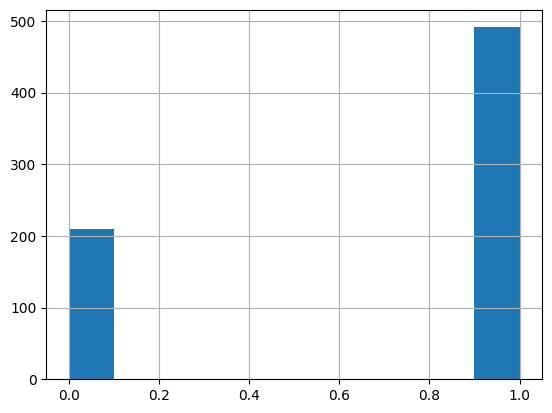

In [30]:
y_train.hist()

<font color='red'> This is a classical example of the unbalanced dataset i.e. one of the classes is twice or more prevalent than the other.</font>

<font color='red'>  Choose a classifier, train it on the training data and predict customer's credict risk (`bad` or `good`) on the test.</font>

In [31]:
#### YOUR CODE STARTS ####
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

xgb1 = xgb.XGBClassifier()
xgb1.fit(X_train, y_train)

res = xgb1.predict_proba(X_test)

auc = roc_auc_score(y_test, res[:,1])
print(f"auc: {auc}")

res = xgb1.predict(X_test)

accuracy = accuracy_score(y_test, res)
print(f"accuracy: {accuracy}")

f1 = f1_score(y_test, res, average='macro')
print(f"f1-score: {f1}")

#### YOUR CODE ENDS ####

auc: 0.7851096272148904
accuracy: 0.7566666666666667
f1-score: 0.68767381166303


<font color='red'> Next, write a function `compute_and_print_metrics` where include four different metrics that we have studied in the class + Matthews Correlation Coefficient (also known as Phi coefficient in statistics), here is the [link](https://en.wikipedia.org/wiki/Phi_coefficient). </font>

In [32]:
def compute_and_print_metrics(y_test, y_pred):
  #### YOUR CODE STARTS ####
  (tp, fn, fp, tn) = compute_confusion_stats(y_test, y_pred, 1, 0)

  precision = tp / (tp + fp)

  recall = tp / (tp + fn)

  if precision + recall == 0:
    f1 = 2 * tp / (2 * tp + fp + fn)
  else:
    f1 = (2 * precision * recall) / (precision + recall)

  mcc = (tp*tn-fp*fn) / np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))


  return precision, recall, f1, mcc
  #### YOUR CODE ENDS ####

<font color='red'> Use `compute_and_print_metrics` to evaluate the model of your choice. </font>

In [33]:
compute_and_print_metrics(y_test, res)

(np.float64(0.7931034482758621),
 np.float64(0.8803827751196173),
 np.float64(0.8344671201814059),
 np.float64(0.3874892511601572))

<font color='red'>  **(Homework exercise 3- b)** Create three balanced versions of the original dataset using:

*   <font color='red'> Oversampling method </font>
*   <font color='red'> Undersampling method </font>
*   <font color='red'> Combination of Over- and Undersampling methods </font>

Select **only** over- and undersampling methods that we have discussed in the regularisation lecture part II. Retrain your chosen classifier on each of the versions and evaluate on the original test set. Store models trained on different versions of the dataset in different variables, they will be useful for the next task.  **(1 point)** </font>


<font color='red'> Below use an **oversampling** approach. </font>

In [34]:
#### YOUR CODE STARTS ####
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler()

X_over, y_over = over.fit_resample(X_train, y_train)
#### YOUR CODE ENDS ####

<Axes: >

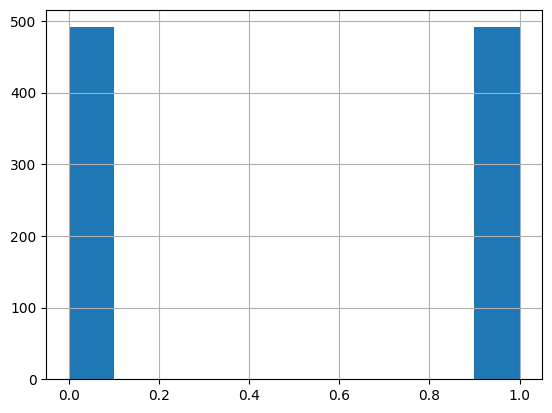

In [35]:
y_over.hist()

<font color='red'> Re-train your classifier on **oversampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>

In [36]:
#### YOUR CODE STARTS ####
xgb_over = xgb.XGBClassifier()

xgb_over.fit(X_over, y_over)

res_over = xgb_over.predict(X_test)
#### YOUR CODE ENDS ####

<font color='red'> Below use an **undersampling** approach. </font>

In [37]:
#### YOUR CODE STARTS ####
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler()

X_under, y_under = under.fit_resample(X_train, y_train)
#### YOUR CODE ENDS ####

<Axes: >

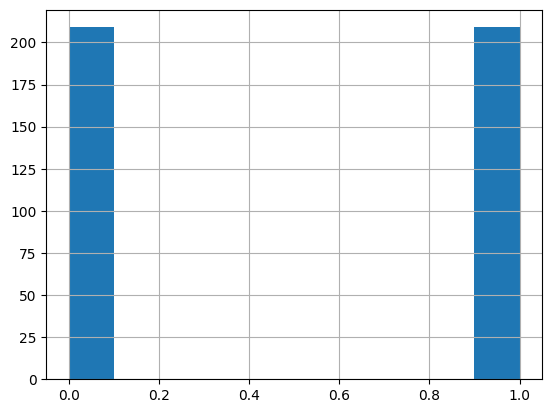

In [38]:
y_under.hist()

<font color='red'> Re-train your classifier on **undersampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>



In [39]:
#### YOUR CODE STARTS ####
xgb_under = xgb.XGBClassifier()

xgb_under.fit(X_under, y_under)

res_under = xgb_under.predict(X_test)
#### YOUR CODE ENDS ####

<font color='red'> Below use an approach that combines **over-** and **undersampling**. </font>

In [40]:
#### YOUR CODE STARTS ####
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

rate = (1 + np.sum(y_train == 1) / len(X_train)) / 2

over_samp = RandomOverSampler(sampling_strategy = rate)
under_samp = RandomUnderSampler()

X_overed, y_overed = over_samp.fit_resample(X_train, y_train)
X_overunder, y_overunder = under_samp.fit_resample(X_overed, y_overed)

print(rate)

print(np.sum(y_train == 1) / len(X_train))
print(1- np.sum(y_train == 1) / len(X_train))


#### YOUR CODE ENDS ####

0.8507142857142858
0.7014285714285714
0.2985714285714286


<Axes: >

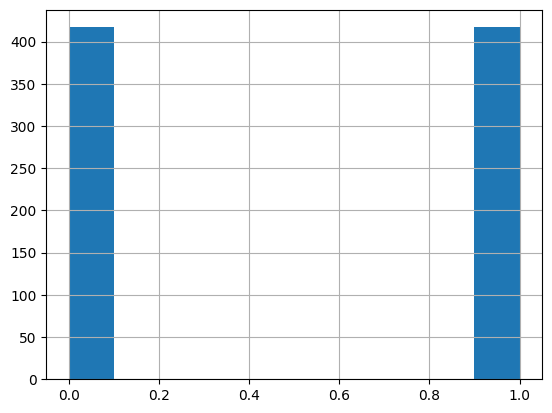

In [41]:
y_overunder.hist()

<font color='red'> Re-train your classifier on **over + undersampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>

In [42]:
#### YOUR CODE STARTS ####
xgb_overunder = xgb.XGBClassifier()

xgb_overunder.fit(X_overunder, y_overunder)

res_overunder = xgb_overunder.predict(X_test)
#### YOUR CODE ENDS ####

<font color='red'>  **(Homework exercise 3- c)** Visualise ROC and PR curves for all four classifiers you have trained. Generate two plots, one for ROC curves and one for PR curves. **(1 point)**</font>


<font color='red'> Below visualise corresponding **ROC** curves. </font>

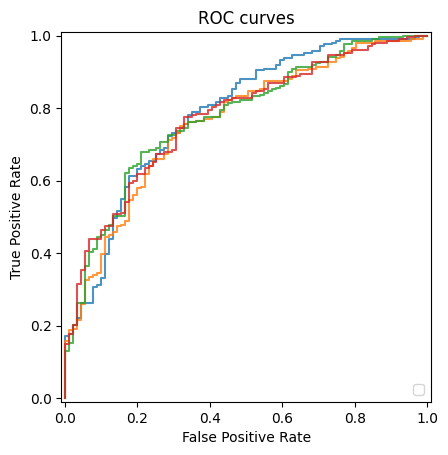

In [49]:
#### YOUR CODE STARTS ####
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

ax = plt.gca()

y_score_base = xgb1.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score_base)
base_disp = RocCurveDisplay(fpr=fpr, tpr=tpr)

y_score_over = xgb_over.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score_over)
over_disp = RocCurveDisplay(fpr=fpr, tpr=tpr)

y_score_under = xgb_under.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score_under)
under_disp = RocCurveDisplay(fpr=fpr, tpr=tpr)

y_score_balance = xgb_overunder.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score_balance)
balance_disp = RocCurveDisplay(fpr=fpr, tpr=tpr)

base_disp.plot(ax=ax, alpha=0.8)
over_disp.plot(ax=ax, alpha=0.8)
under_disp.plot(ax=ax, alpha=0.8)
balance_disp.plot(ax=ax, alpha=0.8)

plt.title("ROC curves")
plt.show()
#### YOUR CODE ENDS ####

<font color='red'> Below visualise corresponding **PR** curves. </font>

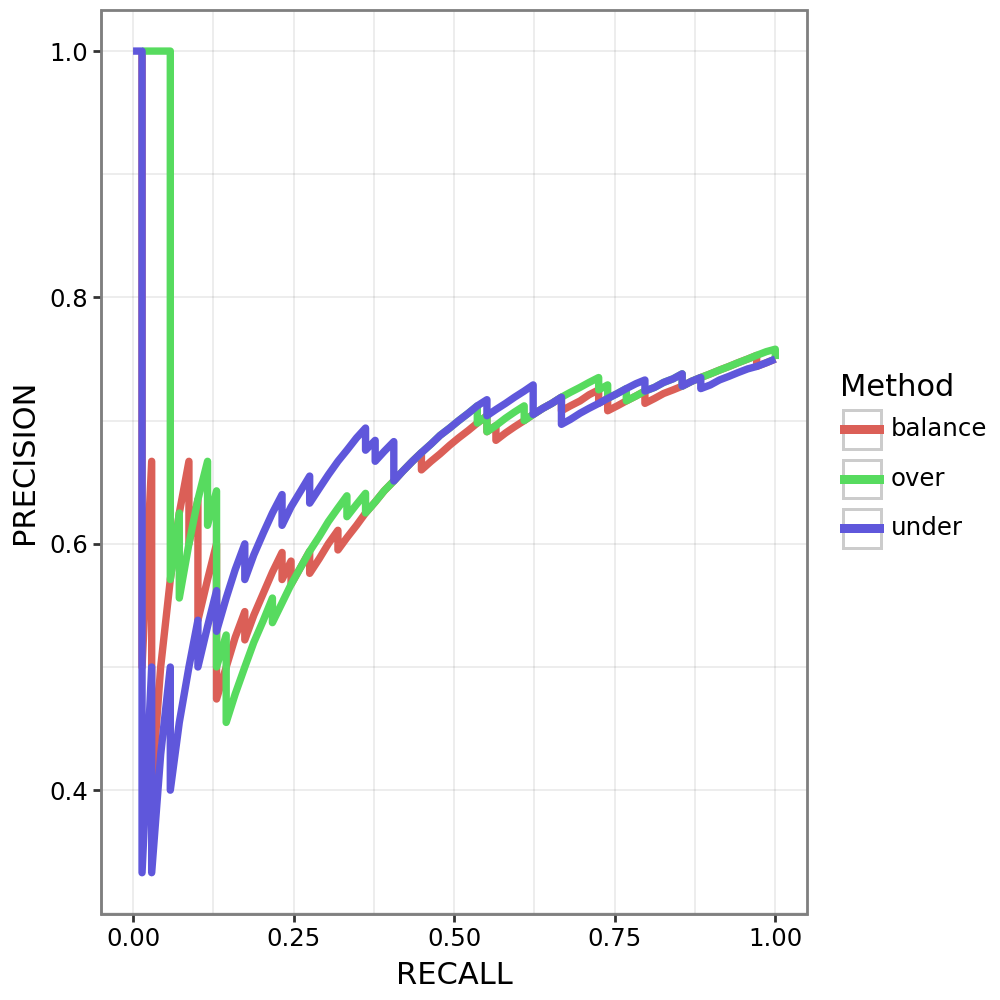

In [50]:
#### YOUR CODE STARTS ####
pr_curve = pd.DataFrame()

pr_curve["xgb_over"] = xgb_over.predict_proba(X_test)[:, 1]
pr_curve["xgb_under"] = xgb_under.predict_proba(X_test)[:, 1]
pr_curve["xgb_underover"] = xgb_overunder.predict_proba(X_test)[:, 1]
pr_curve["y_test"] = y_test

pr_curve = pr_curve.sort_values('xgb_over',  ascending=False)

over_pr_coordinates = generate_PR_coordinates(pr_curve['xgb_over'], pr_curve["y_test"])

top_row = pd.DataFrame({'PRECISION':1, 'RECALL':0}, index=[1.0])

final_xgb_over_pr_coordinates = pd.concat([top_row, over_pr_coordinates])


pr_curve = pr_curve.sort_values('xgb_under',  ascending=False)

under_pr_coordinates = generate_PR_coordinates(pr_curve['xgb_under'], pr_curve["y_test"])

top_row = pd.DataFrame({'PRECISION':1, 'RECALL':0}, index=[1.0])

final_xgb_under_pr_coordinates = pd.concat([top_row, under_pr_coordinates])


pr_curve = pr_curve.sort_values('xgb_underover',  ascending=False)

underover_pr_coordinates = generate_PR_coordinates(pr_curve['xgb_underover'], pr_curve["y_test"])

top_row = pd.DataFrame({'PRECISION':1, 'RECALL':0}, index=[1.0])

final_xgb_underover_pr_coordinates = pd.concat([top_row, underover_pr_coordinates])

plot_pr({
    'over': final_xgb_over_pr_coordinates,
    'under': final_xgb_under_pr_coordinates,
    'balance': final_xgb_underover_pr_coordinates
})

#### YOUR CODE ENDS ####

<font color='red'>  **(Homework exercise 3- d)** Answer the following questions, make sure to sufficiently but not excessively justify your reasoning:
* <font color='red'> Which metric would you choose if you wanted to minimise the number of people you reject as characterised by `bad` credict risk (e.g. you want to avoid lawsuits)? </font>
* <font color='red'> Which metric would you choose if you wanted to make sure that bank does not give loans to people who potentially cannot return it? </font>
* <font color='red'> Which metrics are a good choice when both types of mistakes should be accounted for on unbalanced data? Mention at least two options. </font>

**(1 point)**</font>

Your answers: 1. Precision. The intuition is: if I reject someone, I wanna be as confident as possible that they are actually bad credit risks.
2. Recall, because I want to minimise false negatives and make sure the bank does not miss risky clients.
3. F1-score and ROC-AUC because they account for both types of errors and are suitable for imbalanced datasets.


# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>